# DOTS vs simplify results

This notebook summarizes `compare_dots_simplify.csv`. It separates completed comparisons from cases where simplify was skipped, then visualizes compression, Frechet quality, and runtime.

In [75]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
CSV_PATH = Path.cwd() / 'compare_dots_simplify.csv'
if not CSV_PATH.exists():
    CSV_PATH = Path('results') / 'compare_dots_simplify.csv'
df = pd.read_csv(CSV_PATH).sort_values('id').reset_index(drop=True)
df.head()

,id,baseline_algo,original_points,baseline_points,simplify_points,baseline_frechet,simplify_frechet,baseline_time,simplify_time,best_e,best_d,status
0,1,DOTS,588,120,88,318.872713,317.875705,0.030208,0.017604,317.872713,1.0,ok
1,2,DOTS,1674,757,414,440.341720,439.341720,0.054349,0.025985,439.341720,1.0,ok
2,3,DOTS,1371,168,100,399.500108,398.500108,0.054442,0.019133,398.500108,1.0,ok
3,4,DOTS,672,108,66,343.508902,342.508902,0.030291,0.013974,342.508902,1.0,ok
4,5,DOTS,798,234,148,419.393645,418.393645,0.037074,0.019471,418.393645,1.0,ok


## Coverage and status

In [76]:
numeric_cols = [
    'original_points', 'baseline_points', 'simplify_points',
    'baseline_frechet', 'simplify_frechet', 'baseline_time',
    'simplify_time', 'best_e', 'best_d'
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df['status'] = np.where(
    (df['simplify_points'] > 0) & (df['simplify_frechet'] >= 0),
    'completed', 'simplify skipped'
)
completed = df[df['status'] == 'completed'].copy()
skipped = df[df['status'] != 'completed'].copy()
summary = pd.DataFrame({
    'metric': ['total cases', 'completed comparisons', 'simplify skipped', 'completion rate'],
    'value': [len(df), len(completed), len(skipped), f'{len(completed) / len(df):.1%}' if len(df) else '0.0%']
})
display(summary)
if not skipped.empty:
    display(skipped[['id', 'original_points', 'baseline_points', 'baseline_frechet', 'best_e']])

,metric,value
0,total cases,84
1,completed comparisons,74
2,simplify skipped,10
3,completion rate,88.1%


,id,original_points,baseline_points,baseline_frechet,best_e
7,8,5,5,0.000000,-1.0
21,22,2,2,0.000000,-1.0
30,31,3602,172,-1.000000,-1.0
39,40,7,7,0.000000,-1.0
42,43,5,5,0.000000,-1.0
44,45,3,3,0.000000,-1.0
46,47,8,7,0.000000,-1.0
63,65,1223,543,409.961196,-1.0
65,67,4,2,0.000000,-1.0
67,69,3160,362,-1.000000,-1.0


## Compression and point counts

,metric,DOTS,simplify
0,Mean reduction from original (%),77.90,86.56
1,Median reduction from original (%),79.77,87.79
2,Trajectories where simplify retains fewer points,1.00,1.00
3,Trajectories where DOTS retains fewer points,73.00,73.00
4,Ties,0.00,0.00


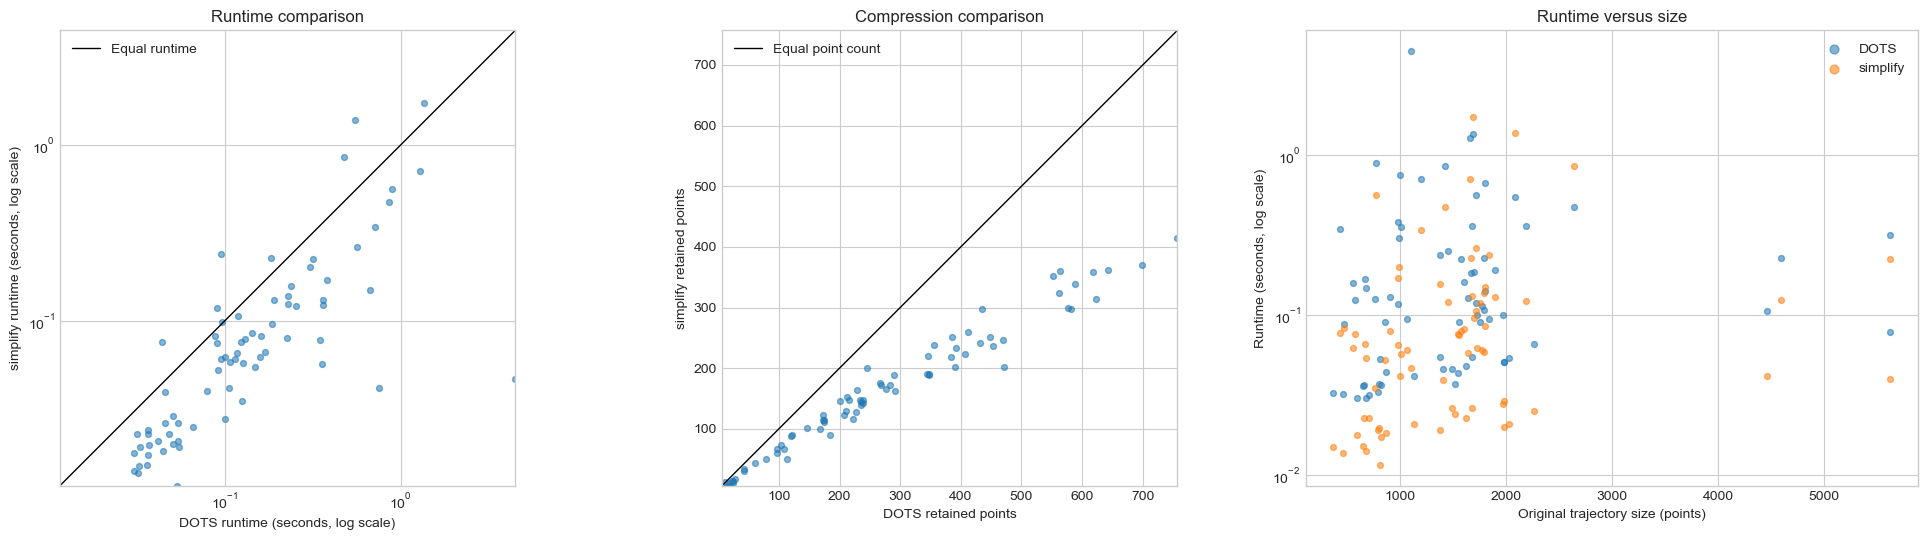

Points below the compression diagonal: simplify retains fewer points than DOTS.
Points above the compression diagonal: DOTS retains fewer points than simplify.


In [77]:
if not completed.empty:
    completed['dots_reduction_pct'] = 100 * (1 - completed['baseline_points'] / completed['original_points'])
    completed['simplify_reduction_pct'] = 100 * (1 - completed['simplify_points'] / completed['original_points'])
    completed['point_difference'] = completed['simplify_points'] - completed['baseline_points']

    summary = pd.DataFrame({
        'metric': [
            'Mean reduction from original (%)',
            'Median reduction from original (%)',
            'Trajectories where simplify retains fewer points',
            'Trajectories where DOTS retains fewer points',
            'Ties',
        ],
        'DOTS': [
            completed['dots_reduction_pct'].mean(),
            completed['dots_reduction_pct'].median(),
            (completed['point_difference'] > 0).sum(),
            (completed['point_difference'] < 0).sum(),
            (completed['point_difference'] == 0).sum(),
        ],
        'simplify': [
            completed['simplify_reduction_pct'].mean(),
            completed['simplify_reduction_pct'].median(),
            (completed['point_difference'] > 0).sum(),
            (completed['point_difference'] < 0).sum(),
            (completed['point_difference'] == 0).sum(),
        ],
    })
    display(summary.round(2))

    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

    time_low = min(completed['baseline_time'].min(), completed['simplify_time'].min())
    time_high = max(completed['baseline_time'].max(), completed['simplify_time'].max())
    axes[0].scatter(completed['baseline_time'], completed['simplify_time'], s=18, alpha=0.55)
    axes[0].plot([time_low, time_high], [time_low, time_high], color='black', linewidth=1, label='Equal runtime')
    axes[0].set(
        xlabel='DOTS runtime (seconds, log scale)',
        ylabel='simplify runtime (seconds, log scale)',
        title='Runtime comparison',
        xscale='log',
        yscale='log',
        xlim=(time_low, time_high),
        ylim=(time_low, time_high),
        aspect='equal',
    )
    axes[0].legend()

    low = min(completed['baseline_points'].min(), completed['simplify_points'].min())
    high = max(completed['baseline_points'].max(), completed['simplify_points'].max())
    axes[1].scatter(completed['baseline_points'], completed['simplify_points'], s=18, alpha=0.55)
    axes[1].plot([low, high], [low, high], color='black', linewidth=1, label='Equal point count')
    axes[1].set(
        xlabel='DOTS retained points',
        ylabel='simplify retained points',
        title='Compression comparison',
        xlim=(low, high),
        ylim=(low, high),
        aspect='equal',
    )
    axes[1].legend()

    size_limit = completed['original_points'].quantile(0.99)
    runtime_by_size = completed[completed['original_points'] <= size_limit].sort_values('original_points')
    axes[2].scatter(runtime_by_size['original_points'], runtime_by_size['baseline_time'], s=18, alpha=0.55, label='DOTS')
    axes[2].scatter(runtime_by_size['original_points'], runtime_by_size['simplify_time'], s=18, alpha=0.55, label='simplify')
    axes[2].set(
        xlabel='Original trajectory size (points)',
        ylabel='Runtime (seconds, log scale)',
        title=f'Runtime versus size',
        yscale='log',
    )
    axes[2].legend(markerscale=1.5)
    plt.tight_layout()
    plt.show()

    print('Points below the compression diagonal: simplify retains fewer points than DOTS.')
    print('Points above the compression diagonal: DOTS retains fewer points than simplify.')

## Benchmark statistics

In [81]:
if not completed.empty:
    completed['dots_retained_pct'] = 100 * completed['baseline_points'] / completed['original_points']
    completed['simplify_retained_pct'] = 100 * completed['simplify_points'] / completed['original_points']
    completed['frechet_change'] = completed['simplify_frechet'] - completed['baseline_frechet']
    completed['frechet_change_pct'] = 100 * completed['frechet_change'] / completed['baseline_frechet'].replace(0, np.nan)
    completed['runtime_ratio'] = completed['simplify_time'] / completed['baseline_time'].replace(0, np.nan)
    completed['speedup'] = completed['baseline_time'] / completed['simplify_time'].replace(0, np.nan)

    statistics = pd.DataFrame(
        {
            'metric': [
                'Completed comparisons',
                'Median DOTS retained points (% of original)',
                'Median simplify retained points (% of original)',
                'Mean additional reduction by simplify (percentage points)',
                'Cases where simplify retains fewer points',
                'Cases where DOTS retains fewer points',
                'Equal retained-point cases',
                'Median Frechet change (simplify - DOTS)',
                'Median relative Frechet change (%)',
                'Median DOTS runtime (seconds)',
                'Median simplify runtime (seconds)',
                'Median simplify / DOTS runtime ratio',
                'Median DOTS speedup over simplify',
                'Cases where simplify is faster',
                'Cases where DOTS is faster',
            ],
            'value': [
                len(completed),
                completed['dots_retained_pct'].median(),
                completed['simplify_retained_pct'].median(),
                (completed['dots_reduction_pct'] - completed['simplify_reduction_pct']).mean(),
                (completed['simplify_points'] < completed['baseline_points']).sum(),
                (completed['baseline_points'] < completed['simplify_points']).sum(),
                (completed['baseline_points'] == completed['simplify_points']).sum(),
                completed['frechet_change'].median(),
                completed['frechet_change_pct'].median(),
                completed['baseline_time'].median(),
                completed['simplify_time'].median(),
                completed['runtime_ratio'].median(),
                completed['speedup'].median(),
                (completed['simplify_time'] < completed['baseline_time']).sum(),
                (completed['baseline_time'] < completed['simplify_time']).sum(),
            ],
        }
    )
    display(statistics.style.format({'value': '{:.4g}'}))

    quantiles = completed[[
        'baseline_points', 'simplify_points', 'baseline_frechet', 'simplify_frechet',
        'baseline_time', 'simplify_time', 'runtime_ratio', 'speedup',
    ]].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T
    display(quantiles[['mean', 'std', 'min', '25%', '50%', '75%', '95%', 'max']].round(4))

    dots_fewer_points = completed.loc[
        completed['baseline_points'] < completed['simplify_points'],
        ['id', 'original_points', 'baseline_points', 'simplify_points'],
    ].copy()
    dots_fewer_points['point_difference'] = (
        dots_fewer_points['simplify_points'] - dots_fewer_points['baseline_points']
    )
    dots_fewer_points = dots_fewer_points.rename(
        columns={
            'id': 'test_case',
            'original_points': 'original_points',
            'baseline_points': 'dots_points',
            'simplify_points': 'simplify_points',
        }
    ).sort_values('test_case')

    print('Cases where DOTS retains fewer points than simplify:')
    display(dots_fewer_points)

,metric,value
0,Completed comparisons,74
1,Median DOTS retained points (% of original),20.23
2,Median simplify retained points (% of original),12.21
3,Mean additional reduction by simplify (percentage points),-8.66
4,Cases where simplify retains fewer points,73
5,Cases where DOTS retains fewer points,1
6,Equal retained-point cases,0
7,Median Frechet change (simplify - DOTS),-1
8,Median relative Frechet change (%),-0.2675
9,Median DOTS runtime (seconds),0.1151


,mean,std,min,25%,50%,75%,95%,max
baseline_points,280.3919,189.9019,11.0000,127.2500,236.5000,403.2500,619.7500,757.0000
simplify_points,165.4324,104.7740,6.0000,90.0000,150.0000,235.5000,358.7000,414.0000
baseline_frechet,338.0939,103.1930,41.3823,277.3173,373.8689,418.1024,438.4379,444.9042
simplify_frechet,337.0947,103.1934,40.3823,276.3173,372.8689,417.1024,437.4388,443.9067
baseline_time,0.2783,0.5680,0.0302,0.0516,0.1151,0.2492,0.8743,4.4995
simplify_time,0.1481,0.2815,0.0115,0.0252,0.0622,0.1236,0.6162,1.7308
runtime_ratio,0.6237,0.4448,0.0103,0.3993,0.5300,0.6368,1.4687,2.5254
speedup,3.5344,11.1950,0.3960,1.5705,1.8869,2.5055,4.5562,96.7889


Cases where DOTS retains fewer points than simplify:


,test_case,original_points,dots_points,simplify_points,point_difference
61,62,1673,11,12,1


## Effect of epsilon on simplification

Results from `scripts/benchmark_e.py`. Each trajectory is run with
`delta = 300 / (1 + epsilon)` for epsilon in {0.25, 0.5, 1, 2, 5, 10, 50, 100}.

Two views:
1. **Simplify ratio** — fraction of points kept, as epsilon grows
2. **Runtime** — simplify core time (SIMPLIFY_CORE_MS) vs epsilon, with the median DOTS runtime for referenceiginal vs simplified (median across IDs)
3. **Runtime** — core algorithm time (SIMPLIFY_CORE_MS) vs epsilon

In [79]:
e_csv = Path('benchmark_e.csv')
if not e_csv.exists():
    e_csv = Path('..') / 'results' / 'benchmark_e.csv'

edf = pd.read_csv(e_csv)

# Keep only successful runs with valid point counts.
edf = edf[(edf['status'] == 'ok') &
          (edf['simplified_points'] > 0) &
          (edf['original_points'] > 0)].copy()

edf['retained_pct'] = 100 * edf['simplified_points'] / edf['original_points']

# Aggregate across trajectories per epsilon.
agg = edf.groupby('epsilon').agg(
    n_ids=('id', 'nunique'),
    median_original=('original_points', 'median'),
    median_simplified=('simplified_points', 'median'),
    median_retained_pct=('retained_pct', 'median'),
    mean_retained_pct=('retained_pct', 'mean'),
    median_core_ms=('core_ms', 'median'),
).reset_index().sort_values('epsilon')

print(f"{len(edf)} rows across {edf['id'].nunique()} trajectories, "
      f"{edf['epsilon'].nunique()} epsilon values")
display(agg)

2824 rows across 353 trajectories, 8 epsilon values


,epsilon,n_ids,median_original,median_simplified,median_retained_pct,mean_retained_pct,median_core_ms
0,0.25,353,1408.0,148.0,13.084112,16.766232,4303.3785
1,0.50,353,1408.0,148.0,13.195640,16.831796,1354.4203
2,1.00,353,1408.0,150.0,13.373860,17.031157,309.6850
3,2.00,353,1408.0,164.0,14.707521,18.258335,43.9077
4,5.00,353,1408.0,178.0,16.644993,19.988231,24.6518
5,10.00,353,1408.0,170.0,15.843621,19.216978,24.0120
6,50.00,353,1408.0,166.0,15.151515,18.497688,24.6360
7,100.00,353,1408.0,166.0,14.918415,18.420218,22.8959


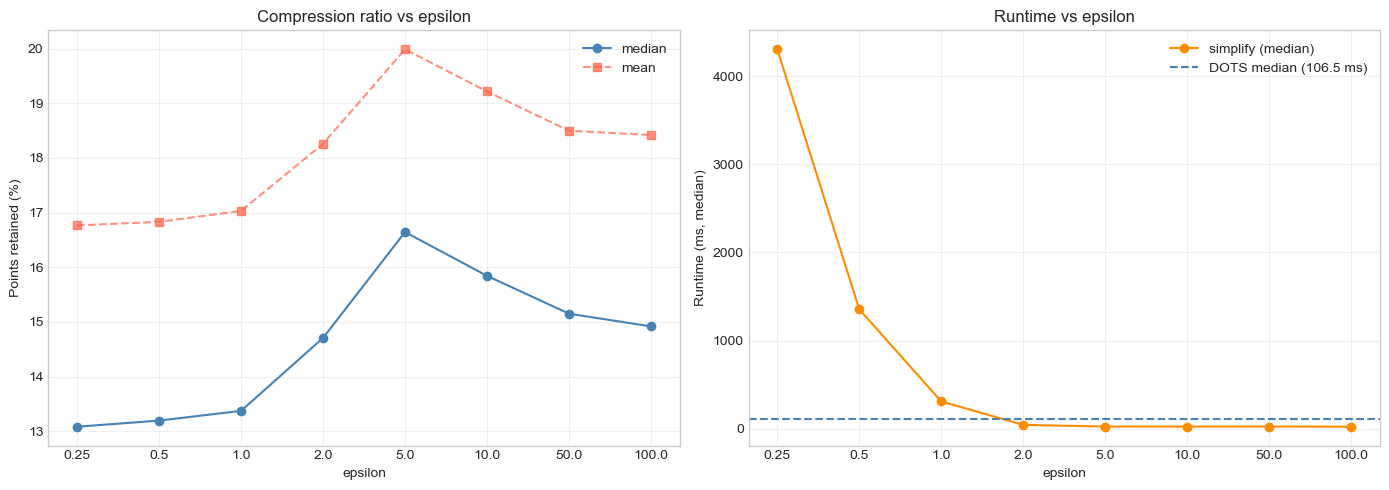

In [80]:
# Load DOTS median runtime from the main comparison CSV (baseline_time is in seconds).
dots_csv = Path('compare_dots_simplify.csv')
if not dots_csv.exists():
    dots_csv = Path('..') / 'results' / 'compare_dots_simplify.csv'
dots_df = pd.read_csv(dots_csv)
dots_df['baseline_time'] = pd.to_numeric(dots_df['baseline_time'], errors='coerce')
dots_median_ms = dots_df['baseline_time'].median() * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eps_vals = agg['epsilon'].values
x = range(len(eps_vals))
x_labels = [str(e) if e == int(e) else str(e) for e in eps_vals]

# --- Plot 1: simplify ratio ---
ax = axes[0]
ax.plot(x, agg['median_retained_pct'], 'o-', color='steelblue', label='median')
ax.plot(x, agg['mean_retained_pct'], 's--', color='tomato', alpha=0.7, label='mean')
ax.set_xticks(list(x))
ax.set_xticklabels(x_labels)
ax.set_xlabel('epsilon')
ax.set_ylabel('Points retained (%)')
ax.set_title('Compression ratio vs epsilon')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: runtime ---
ax = axes[1]
ax.plot(x, agg['median_core_ms'], 'o-', color='darkorange', label='simplify (median)')
ax.axhline(dots_median_ms, linestyle='--', color='steelblue',
           label=f'DOTS median ({dots_median_ms:.1f} ms)')
ax.set_xticks(list(x))
ax.set_xticklabels(x_labels)
ax.set_xlabel('epsilon')
ax.set_ylabel('Runtime (ms, median)')
ax.set_title('Runtime vs epsilon')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('epsilon_effect.png', dpi=150, bbox_inches='tight')
plt.show()